# 第一部分
本文件是测试用，对单独的img文件进行处理，确保前期处理方法无误。先将img文件读成一维数组，从lbl文件找到img文件行数列数，改成二维矩阵，并生成图片

{'image_name': 'S_00282302_RGRAM.IMG', 'lines': 3600, 'samples': 4721, 'sample_type': 'PC_REAL', 'sample_bits': 32}
(3600, 4721)
float32
2.5218183e-06 0.42529476


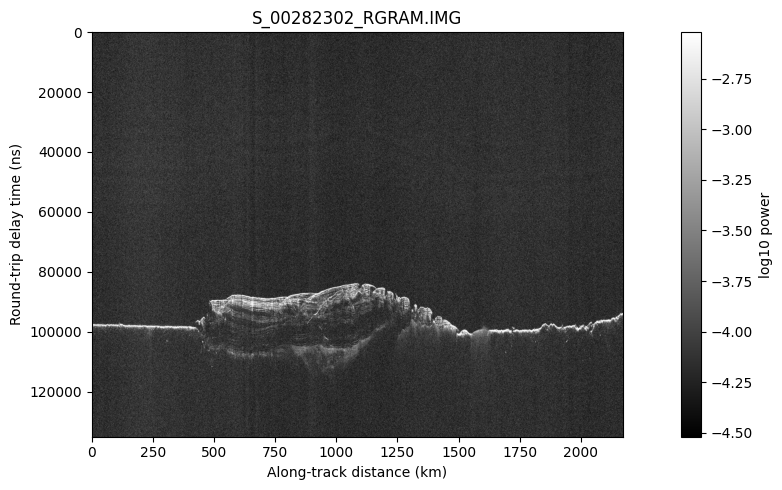

使用 geom 文件：geom_data_total\s_0028xx\s_00282302_geom.tab
经度范围: 0.0532 359.9561
纬度范围: 70.0657 87.3043
DEM CRS:
PROJCS["PolarStereographic Mars",GEOGCS["GCS_Mars",DATUM["D_Mars",SPHEROID["Mars_polarRadius",3396190,0]],PRIMEM["Reference_Meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",90],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",SOUTH],AXIS["Northing",SOUTH]]
DEM extent: [-1820381.5309664, 1819918.4473919997, -1819918.4473919997, 1820381.5309664]
DEM center x: -231.5417872001417
DEM center y: 231.5417872001417
北纬 60° 以上点数: 4721
进入图中区域的起始点：
  lon = 42.1
  lat = 72.8085


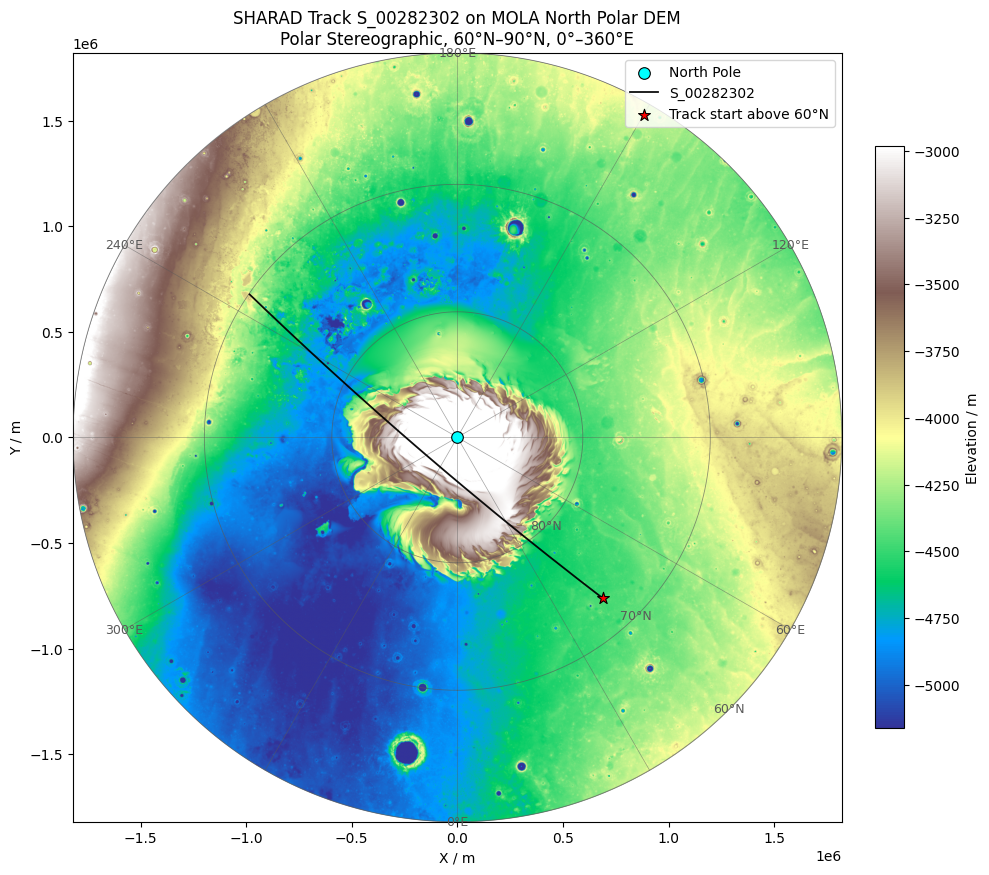

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'SHARAD Track S_00282302 on MOLA North Polar DEM\nPolar Stereographic, 60°N–90°N, 0°–360°E'}, xlabel='X / m', ylabel='Y / m'>)

In [1]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d, median_filter
import polar_picture_draw
def parse_rgram_lbl(lbl_path):
    """
    读取 SHARAD RGRAM 的 PDS3 .LBL 文件，提取 IMG 读取所需信息
    """
    lbl_path = Path(lbl_path)
    text = lbl_path.read_text(errors="ignore")

    def get_int(key):
        m = re.search(rf"\b{key}\s*=\s*(\d+)", text)
        if m is None:
            raise ValueError(f"LBL 中没有找到 {key}")
        return int(m.group(1))

    def get_str(key):
        m = re.search(rf"\b{key}\s*=\s*\"?([^\"\n]+)\"?", text)
        if m is None:
            raise ValueError(f"LBL 中没有找到 {key}")
        return m.group(1).strip()

    # ^IMAGE 比较特殊，前面有 ^
    m = re.search(r"\^IMAGE\s*=\s*\"([^\"]+)\"", text)
    if m is None:
        raise ValueError("LBL 中没有找到 ^IMAGE")
    image_name = m.group(1)

    lines = get_int("LINES")
    samples = get_int("LINE_SAMPLES")
    sample_type = get_str("SAMPLE_TYPE")
    sample_bits = get_int("SAMPLE_BITS")

    return {
        "image_name": image_name,
        "lines": lines,
        "samples": samples,
        "sample_type": sample_type,
        "sample_bits": sample_bits,
    }


def read_rgram_img_from_lbl(lbl_path):
    """
    根据 RGRAM.LBL 读取对应的 RGRAM.IMG
    """
    lbl_path = Path(lbl_path)
    info = parse_rgram_lbl(lbl_path)

    img_path = lbl_path.with_name(info["image_name"])

    if not img_path.exists():
        raise FileNotFoundError(f"没有找到对应的 IMG 文件：{img_path}")

    sample_type = info["sample_type"]
    sample_bits = info["sample_bits"]

    if sample_type == "PC_REAL" and sample_bits == 32:
        dtype = "<f4"   # 小端 float32
    else:
        raise ValueError(f"暂不支持的数据格式：{sample_type}, {sample_bits} bits")

    data = np.fromfile(img_path, dtype=dtype)

    expected_size = info["lines"] * info["samples"]

    if data.size != expected_size:
        raise ValueError(
            f"文件大小不匹配：读取到 {data.size} 个数，"
            f"但 LBL 期望 {expected_size} 个数"
        )

    data = data.reshape((info["lines"], info["samples"]))

    return data, info


def show_rgram(data, title="RGRAM", dx_m=460.0, dt_ns=37.5):
    """
    显示 SHARAD RGRAM 雷达图

    data shape: (sample, line)

    横轴：沿轨距离，单位 km
    纵轴：双程雷达延迟时间，单位 ns

    同时保持原始 data 的图像比例
    """

    img_log = np.log10(data + 1e-8)

    vmin = np.percentile(img_log, 5)
    vmax = np.percentile(img_log, 99.8)

    nsample, nline = data.shape

    # 横轴：km
    x_min = 0
    x_max = (nline - 1) * dx_m / 1000.0

    # 纵轴：ns
    y_min = 0
    y_max = (nsample - 1) * dt_ns

    # 关键：计算 aspect，让显示比例保持为 data 原始比例
    # 原始图像宽高比 = nline / nsample
    # 坐标轴单位范围已经变成 km 和 ns，所以需要修正 aspect
    aspect = (x_max - x_min) / (y_max - y_min) * (nsample / nline)

    plt.figure(figsize=(12, 5))

    plt.imshow(
        img_log,
        cmap="gray",
        origin="upper",
        extent=[x_min, x_max, y_max, y_min],
        aspect=aspect,
        vmin=vmin,
        vmax=vmax
    )

    plt.colorbar(label="log10 power")
    plt.xlabel("Along-track distance (km)")
    plt.ylabel("Round-trip delay time (ns)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

lbl_path = r".\rgram\S_00282302_rgram.lbl"

data, info = read_rgram_img_from_lbl(lbl_path)

print(info)
print(data.shape)
print(data.dtype)
print(data.min(), data.max())




show_rgram(data, info["image_name"])
polar_picture_draw.main(info["image_name"])

# 第二部分
本段用以筛选出地表反射层，地下噪声层，电离层

In [2]:
def pick_surface_from_data(img, top_ratio=0.50, bottom_ratio=1.00, window=5):
    """
    img shape: (height, width)

    只在图像下半部分寻找 surface。
    
    返回：
        surface_y，长度为 width
        surface_y[x] 表示第 x 列对应的 surface 高度位置 y
    """
    height, width = img.shape

    y_top = int(height * top_ratio)
    y_bottom = int(height * bottom_ratio)

    y_top = max(0, y_top)
    y_bottom = min(height, y_bottom)

    img_search = img[y_top:y_bottom, :]

    safe_data = np.nan_to_num(img_search, nan=-np.inf)

    if img_search.shape[0] < window:
        surface_y = np.argmax(safe_data, axis=0) + y_top
        return surface_y.astype(int)

    windows = np.lib.stride_tricks.sliding_window_view(
        safe_data,
        window_shape=window,
        axis=0
    )

    window_strength = np.max(windows, axis=2)

    surface_y = np.argmax(window_strength, axis=0) + window // 2 + y_top

    return surface_y.astype(int)


def subtract_bottom_noise_mean(data, bottom_ratio=0.10):
    """
    data shape: (nline, nsample)

    使用图像底部 bottom_ratio 的区域估计噪声平均值，
    然后整张图减去这个平均噪声值。

    返回：
        data_corrected: 减去噪声均值后的矩阵
        noise_mean: 底部噪声区平均值
        bottom_noise_mask: 底部噪声区域 mask
    """

    nline, nsample = data.shape

    # 底部 10% 的起始位置
    noise_start = int(nline * (1 - bottom_ratio))

    # 构造底部噪声 mask
    bottom_noise_mask = np.zeros_like(data, dtype=bool)
    bottom_noise_mask[noise_start:, :] = True

    # 取出底部噪声区
    noise_region = data[bottom_noise_mask]
    if noise_region.size == 0:
        raise ValueError(
            "bottom_ratio 太小，无法构造底部噪声区域。"
        )

    # 计算噪声平均值，忽略 NaN
    noise_mean = np.nanmean(noise_region)

    # 整张图减去噪声平均值
    data_corrected = data - noise_mean

    return data_corrected, noise_mean, bottom_noise_mask

def make_three_masks_simple(img, surface,
                            bottom_noise_ratio=0.10,
                            margin_above=20,
                            margin_surface=5,
                            reflection_depth=180):
    """
    img shape: (nline, nsample)

    nline:
        纵坐标，高度

    nsample:
        横坐标，宽度

    surface shape: (nsample,)

    surface[x]:
        第 x 列的地表 y 坐标

    返回：
        ionosphere_mask:
            surface 最上面的点以上的区域，全部忽略

        reflection_mask:
            每一列 surface 以下的候选地下反射区

        noise_mask:
            图像底部 bottom_noise_ratio 的固定噪声区
    """

    nline, nsample = img.shape

    surface = np.asarray(surface).astype(int)

    if surface.shape[0] != nsample:
        raise ValueError(
            f"surface 长度应该等于 nsample={nsample}，"
            f"但现在 surface 长度是 {surface.shape[0]}"
        )

    ionosphere_mask = np.zeros_like(img, dtype=bool)
    reflection_mask = np.zeros_like(img, dtype=bool)
    noise_mask = np.zeros_like(img, dtype=bool)

    # 1. surface 最上面的点
    surface_top = np.nanmin(surface)

    # 2. surface 最上面的点以上全部忽略
    ignore_end = max(0, surface_top - margin_above)
    ionosphere_mask[:ignore_end, :] = True

    # 3. 每一列生成地下反射候选区
    for x in range(nsample):
        ys = surface[x]

        ys = np.clip(ys, 0, nline - 1)

        refl_start = min(nline, ys + margin_surface)
        refl_end = min(nline, ys + reflection_depth)

        reflection_mask[refl_start:refl_end, x] = True

    # 4. 图像底部 10% 固定作为噪声区
    noise_start = int(nline * (1 - bottom_noise_ratio))
    noise_mask[noise_start:, :] = True

    return ionosphere_mask, reflection_mask, noise_mask

surface = pick_surface_from_data(data, top_ratio=0.50, bottom_ratio=1.00, window=5)

# 1. 每列用底部 10% 做噪声背景校正
data_corrected, noise_mean, bottom_noise_mask = subtract_bottom_noise_mean(
    data,
    bottom_ratio=0.10
)

# 2. 生成 mask
ionosphere_mask, reflection_mask, noise_mask = make_three_masks_simple(
    data_corrected,
    surface,
    bottom_noise_ratio=0.10,
    margin_above=20,
    margin_surface=5,
    reflection_depth=180
)

# 3. 检查结果
print("data_corrected:", data_corrected.shape)
print("surface:", surface.shape)
print("ionosphere_mask:", ionosphere_mask.shape)
print("reflection_mask:", reflection_mask.shape)
print("noise_mask:", noise_mask.shape)






data_corrected: (3600, 1099)
surface: (1099,)
ionosphere_mask: (3600, 1099)
reflection_mask: (3600, 1099)
noise_mask: (3600, 1099)


C:\Users\hp\AppData\Local\Temp\ipykernel_40948\4073178345.py:93: RuntimeWarning: invalid value encountered in log10
  img_log = np.log10(data + 1e-8)


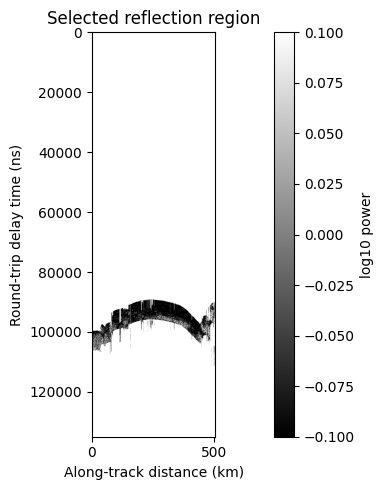

In [3]:
# 4. 只保留筛选出来的反射候选区，其他位置不显示

selected_mask = reflection_mask & (~ionosphere_mask) & (~noise_mask)

selected_data = np.full_like(data_corrected, np.nan, dtype=float)
selected_data[selected_mask] = data_corrected[selected_mask]

show_rgram(selected_data, title="Selected reflection region")

# 第三部分

本部分是根据mask生成反射层的图片,一是要把所有所有反射层顶点移动到同一高度,然后得到Reflection_data,生成图片

reflection_data: (175, 1099)
reflection_valid_mask: (175, 1099)


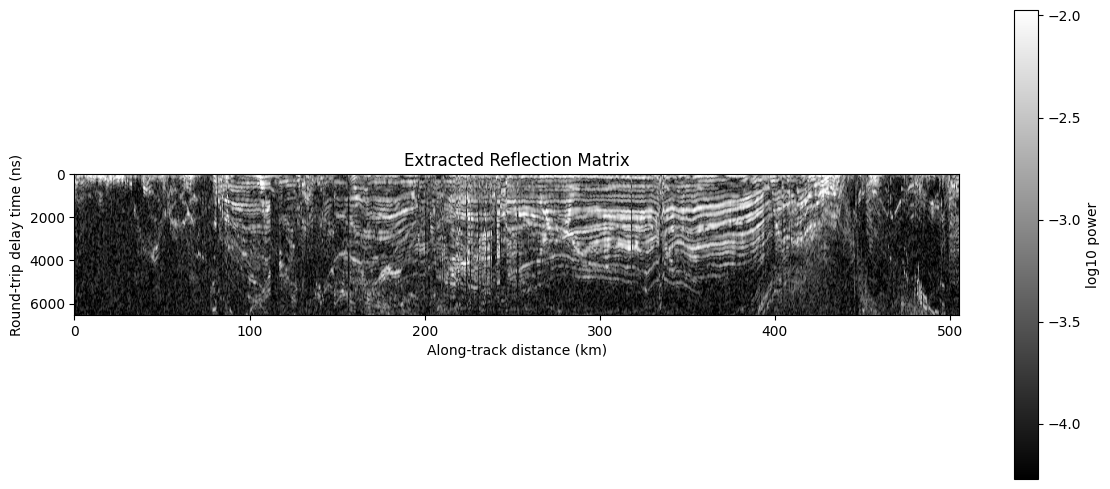

In [4]:
def extract_reflection_matrix(data, surface,
                              margin_surface=5,
                              reflection_depth=180,
                              fill_value=0.0):
    """
    从 data 中提取沿 surface 对齐的地下反射层小矩阵。

    data shape:
        (nline, nsample)
        nline 是纵坐标高度
        nsample 是横坐标宽度

    surface shape:
        (nsample,)

    返回：
        reflection_data:
            小矩阵，shape = (reflection_depth - margin_surface, nsample)

        reflection_valid_mask:
            有效区域 mask，shape 和 reflection_data 相同
    """

    nline, nsample = data.shape

    surface = np.asarray(surface).astype(int)

    if surface.shape[0] != nsample:
        raise ValueError(
            f"surface 长度应该等于 nsample={nsample}，"
            f"但现在是 {surface.shape[0]}"
        )

    out_height = reflection_depth - margin_surface

    if out_height <= 0:
        raise ValueError("reflection_depth 必须大于 margin_surface")

    reflection_data = np.full(
        (out_height, nsample),
        fill_value,
        dtype=np.float32
    )

    reflection_valid_mask = np.zeros(
        (out_height, nsample),
        dtype=bool
    )

    for x in range(nsample):
        ys = surface[x]

        start_y = ys + margin_surface
        end_y = ys + reflection_depth

        src_start = max(0, start_y)
        src_end = min(nline, end_y)

        if src_start >= src_end:
            continue

        dst_start = src_start - start_y
        dst_end = dst_start + (src_end - src_start)

        reflection_data[dst_start:dst_end, x] = data[src_start:src_end, x]
        reflection_valid_mask[dst_start:dst_end, x] = True

    return reflection_data, reflection_valid_mask

reflection_data, reflection_valid_mask = extract_reflection_matrix(
    data,
    surface,
    margin_surface=5,
    reflection_depth=180,
    fill_value=0.0
)

print("reflection_data:", reflection_data.shape)
print("reflection_valid_mask:", reflection_valid_mask.shape)

show_rgram(reflection_data, "Extracted Reflection Matrix")

# 第四部分
得到底部噪声，每张图配备自己的底部噪声用以训练

In [5]:
def extract_noise_matrix_from_bottom(data,
                                     target_shape,
                                     bottom_ratio=0.10,
                                     random_crop=True,
                                     seed=None):
    """
    从图像底部噪声区提取一个和 target_shape 同样大小的噪声矩阵。

    data shape:
        (nline, nsample)

    target_shape:
        目标噪声矩阵大小，例如 reflection_data.shape

    bottom_ratio:
        使用图像底部多少比例作为噪声来源

    random_crop:
        True  表示在底部噪声区随机裁剪
        False 表示直接取底部最后 target_height 行

    返回：
        noise_data:
            shape = target_shape
    """

    rng = np.random.default_rng(seed)

    nline, nsample = data.shape
    target_height, target_width = target_shape

    if target_width != nsample:
        raise ValueError(
            f"target_width 应该等于原图宽度 nsample={nsample}，"
            f"但现在 target_width={target_width}"
        )

    # 底部噪声区起始位置
    noise_start = int(nline * (1 - bottom_ratio))

    # 取出底部噪声区域
    bottom_noise_region = data[noise_start:, :]

    noise_height = bottom_noise_region.shape[0]

    if noise_height <= 0:
        raise ValueError("bottom_ratio 太小，无法获得底部噪声区。")

    # 情况 1：底部噪声区高度足够，直接裁剪
    if noise_height >= target_height:
        if random_crop:
            max_start = noise_height - target_height
            start = rng.integers(0, max_start + 1)
        else:
            start = noise_height - target_height

        noise_data = bottom_noise_region[start:start + target_height, :]

    # 情况 2：底部噪声区不够高，就有放回抽样
    else:
        row_idx = rng.integers(0, noise_height, size=target_height)
        noise_data = bottom_noise_region[row_idx, :]

    noise_data = np.asarray(noise_data, dtype=np.float32)

    # 再次让噪声均值接近 0
    noise_data = noise_data - np.nanmean(noise_data)

    # 防止 NaN
    noise_data = np.nan_to_num(noise_data, nan=0.0)

    return noise_data

noise_data = extract_noise_matrix_from_bottom(
    data_corrected,
    target_shape=reflection_data.shape,
    bottom_ratio=0.10,
    random_crop=True,
    seed=0
)

print("reflection_data:", reflection_data.shape)
print("noise_data:", noise_data.shape)

reflection_data: (175, 1099)
noise_data: (175, 1099)


noise_scale: 0.35
noise_gain: 11.67322500518003
reflection_with_bottom_noise: (175, 1099)


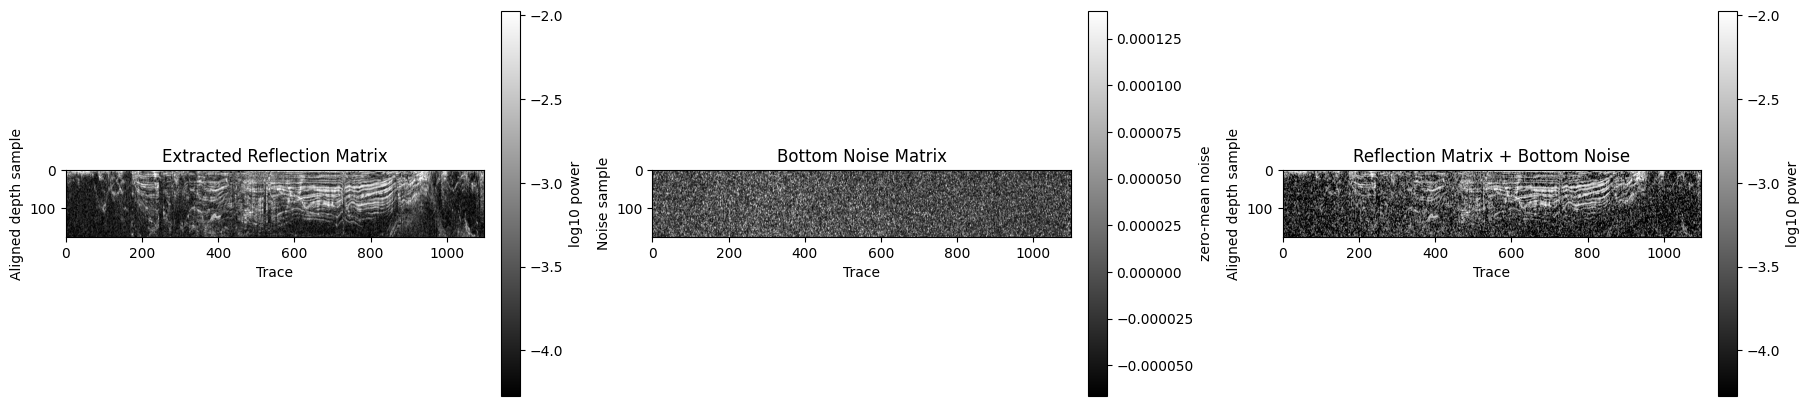

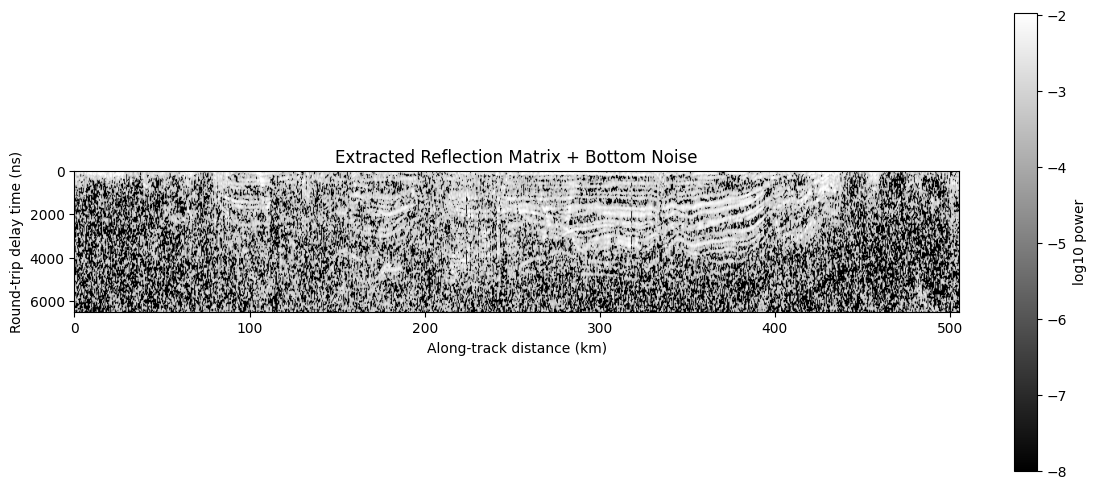

In [6]:
def add_bottom_noise_to_reflection(reflection_data, noise_data, valid_mask=None, noise_scale=0.35):
    """
    将底部噪声按反射矩阵的幅值尺度加入 Extracted Reflection Matrix。

    noise_scale 越大，加入的底部噪声越明显。
    """

    reflection = np.asarray(reflection_data, dtype=np.float32)
    noise = np.asarray(noise_data, dtype=np.float32)

    if reflection.shape != noise.shape:
        raise ValueError(
            f"reflection_data 和 noise_data 的形状必须一致，"
            f"现在分别是 {reflection.shape} 和 {noise.shape}"
        )

    if valid_mask is None:
        valid_mask = np.ones_like(reflection, dtype=bool)
    else:
        valid_mask = np.asarray(valid_mask, dtype=bool)

    signal_std = np.nanstd(reflection[valid_mask])
    noise_std = np.nanstd(noise[valid_mask])

    if noise_std <= 0 or not np.isfinite(noise_std):
        noise_gain = 0.0
    else:
        noise_gain = noise_scale * signal_std / noise_std

    reflection_with_noise = reflection.copy()
    reflection_with_noise[valid_mask] = (
        reflection[valid_mask] + noise[valid_mask] * noise_gain
    )

    # RGRAM 是功率图，显示前保持非负，避免 log10 出现无效值。
    reflection_with_noise = np.clip(reflection_with_noise, 0.0, None)

    return reflection_with_noise, noise_gain


def show_reflection_noise_effect(reflection_data, noise_data, reflection_with_noise):
    """对比显示原始反射矩阵、底部噪声和加噪后的效果。"""

    eps = 1e-8
    reflection_log = np.log10(np.clip(reflection_data, eps, None))
    noisy_log = np.log10(np.clip(reflection_with_noise, eps, None))

    vmin = np.nanpercentile(reflection_log, 5)
    vmax = np.nanpercentile(reflection_log, 99.8)
    noise_vmin = np.nanpercentile(noise_data, 1)
    noise_vmax = np.nanpercentile(noise_data, 99)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    im0 = axes[0].imshow(reflection_log, cmap="gray", origin="upper", vmin=vmin, vmax=vmax)
    axes[0].set_title("Extracted Reflection Matrix")
    axes[0].set_xlabel("Trace")
    axes[0].set_ylabel("Aligned depth sample")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="log10 power")

    im1 = axes[1].imshow(noise_data, cmap="gray", origin="upper", vmin=noise_vmin, vmax=noise_vmax)
    axes[1].set_title("Bottom Noise Matrix")
    axes[1].set_xlabel("Trace")
    axes[1].set_ylabel("Noise sample")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="zero-mean noise")

    im2 = axes[2].imshow(noisy_log, cmap="gray", origin="upper", vmin=vmin, vmax=vmax)
    axes[2].set_title("Reflection Matrix + Bottom Noise")
    axes[2].set_xlabel("Trace")
    axes[2].set_ylabel("Aligned depth sample")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="log10 power")

    plt.show()


noise_scale = 0.35
reflection_with_bottom_noise, noise_gain = add_bottom_noise_to_reflection(
    reflection_data,
    noise_data,
    valid_mask=reflection_valid_mask,
    noise_scale=noise_scale
)

print("noise_scale:", noise_scale)
print("noise_gain:", noise_gain)
print("reflection_with_bottom_noise:", reflection_with_bottom_noise.shape)

show_reflection_noise_effect(
    reflection_data,
    noise_data,
    reflection_with_bottom_noise
)

show_rgram(reflection_with_bottom_noise, "Extracted Reflection Matrix + Bottom Noise")


In [ ]:
# 2. 划分数据集
read npz_stats.csv
filter status == ok
group files by track_id
split into train / val / test
save split.json, train.txt, val.txt, test.txt

# 3. 构建 Dataset
class RadarPatchDataset:
    for each npz_file in split:
        read reflection, noise
        random crop patch of size patch_h x patch_w
        noisy_patch = reflection_patch + alpha * noise_patch
        normalize reflection_patch and noisy_patch using log1p + p1/p99
        mask = valid region of reflection_patch (padding / NaN excluded)
        return noisy, reflection, mask, alpha, file, track_id

# 4. 定义模型
class ResidualUNet:
    input: noisy_patch
    output: predicted_noise
    denoised = noisy_patch - predicted_noise
    network structure:
        encoder: multiple downsampling ConvBlocks
        decoder: upsampling ConvBlocks with skip connections
        residual learning: predict noise, not clean image

# 5. 训练模型
for epoch in range(max_epochs):
    for batch in train_loader:
        pred_noise = model(noisy)
        denoised = noisy - pred_noise
        loss = SmoothL1Loss(denoised, reflection, mask)
        backpropagate and update weights
    validate on val_loader
    save best checkpoint and preview images

# 6. 推理完整雷达图
for npz_file in test_split:
    read reflection matrix
    slide a window of size patch_h x patch_w across width with overlap
    for each patch:
        pred_noise = model(patch)
        denoised_patch = patch - pred_noise
    merge patches to reconstruct full denoised matrix
    save denoised_norm, denoised_raw_approx, predicted_noise, residual
    optionally save preview PNGs for visualization